## import libraries and Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('Heart_Disease_Prediction.csv')

## Data Exploration

In [22]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [23]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [25]:
df.describe().round()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.0,270.0,270.0,270.0,270.0,270.0,270.0,270.0,270.0,270.0,270.0,270.0,270.0
mean,54.0,1.0,3.0,131.0,250.0,0.0,1.0,150.0,0.0,1.0,2.0,1.0,5.0
std,9.0,0.0,1.0,18.0,52.0,0.0,1.0,23.0,0.0,1.0,1.0,1.0,2.0
min,29.0,0.0,1.0,94.0,126.0,0.0,0.0,71.0,0.0,0.0,1.0,0.0,3.0
25%,48.0,0.0,3.0,120.0,213.0,0.0,0.0,133.0,0.0,0.0,1.0,0.0,3.0
50%,55.0,1.0,3.0,130.0,245.0,0.0,2.0,154.0,0.0,1.0,2.0,0.0,3.0
75%,61.0,1.0,4.0,140.0,280.0,0.0,2.0,166.0,1.0,2.0,2.0,1.0,7.0
max,77.0,1.0,4.0,200.0,564.0,1.0,2.0,202.0,1.0,6.0,3.0,3.0,7.0


In [26]:
df.isna().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

## data preprocessing

In [28]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
df['Heart Disease'] = lab.fit_transform(df['Heart Disease'])

In [29]:
df['Heart Disease'] 

0      1
1      0
2      1
3      0
4      0
      ..
265    0
266    0
267    0
268    0
269    1
Name: Heart Disease, Length: 270, dtype: int64

## Data analysis and visualization (EDA)

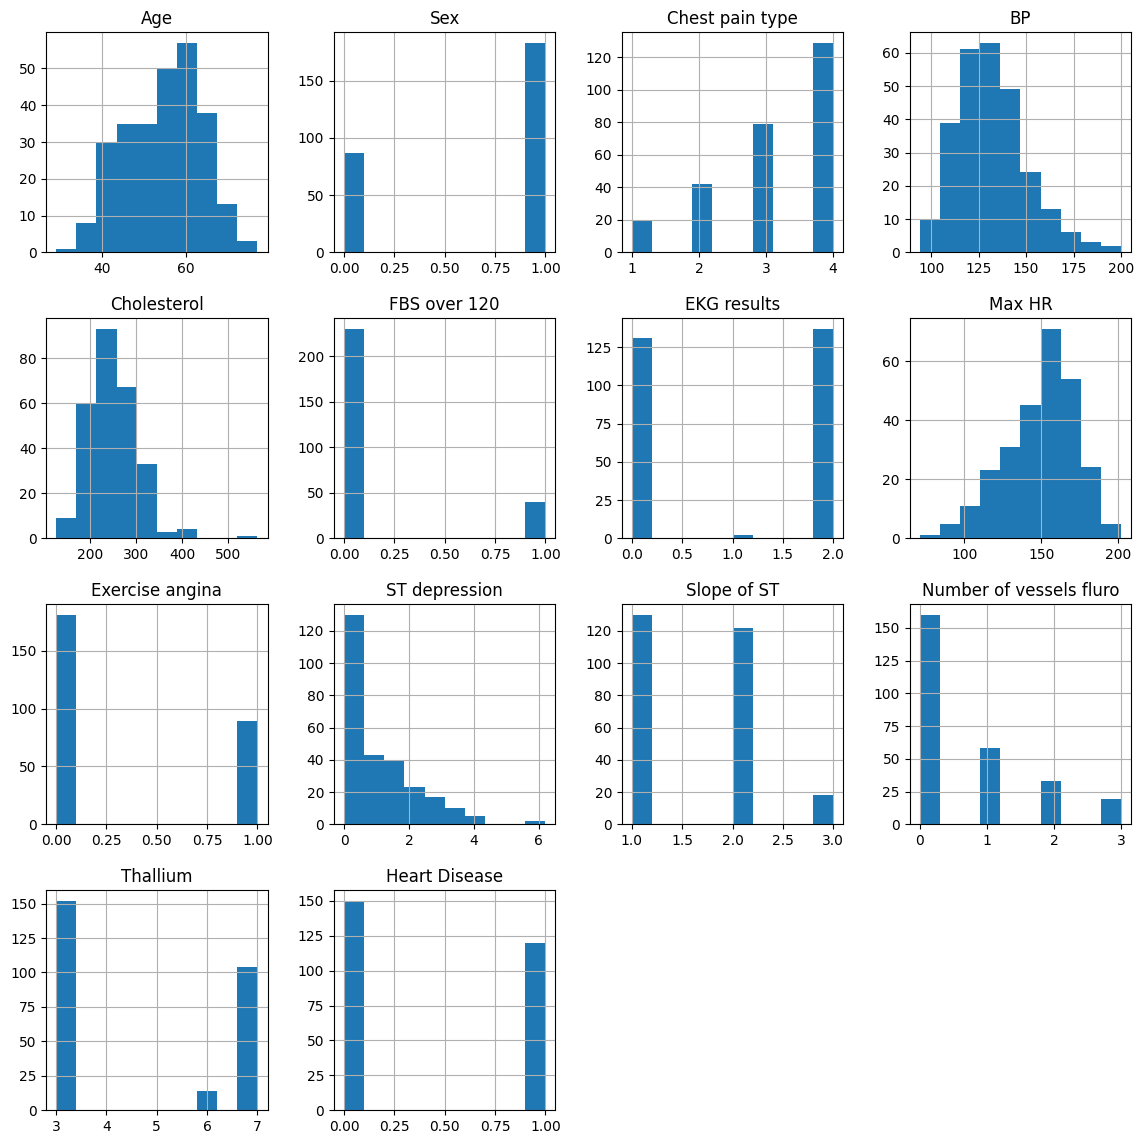

In [30]:
df.hist(figsize=(14,14))
plt.show()

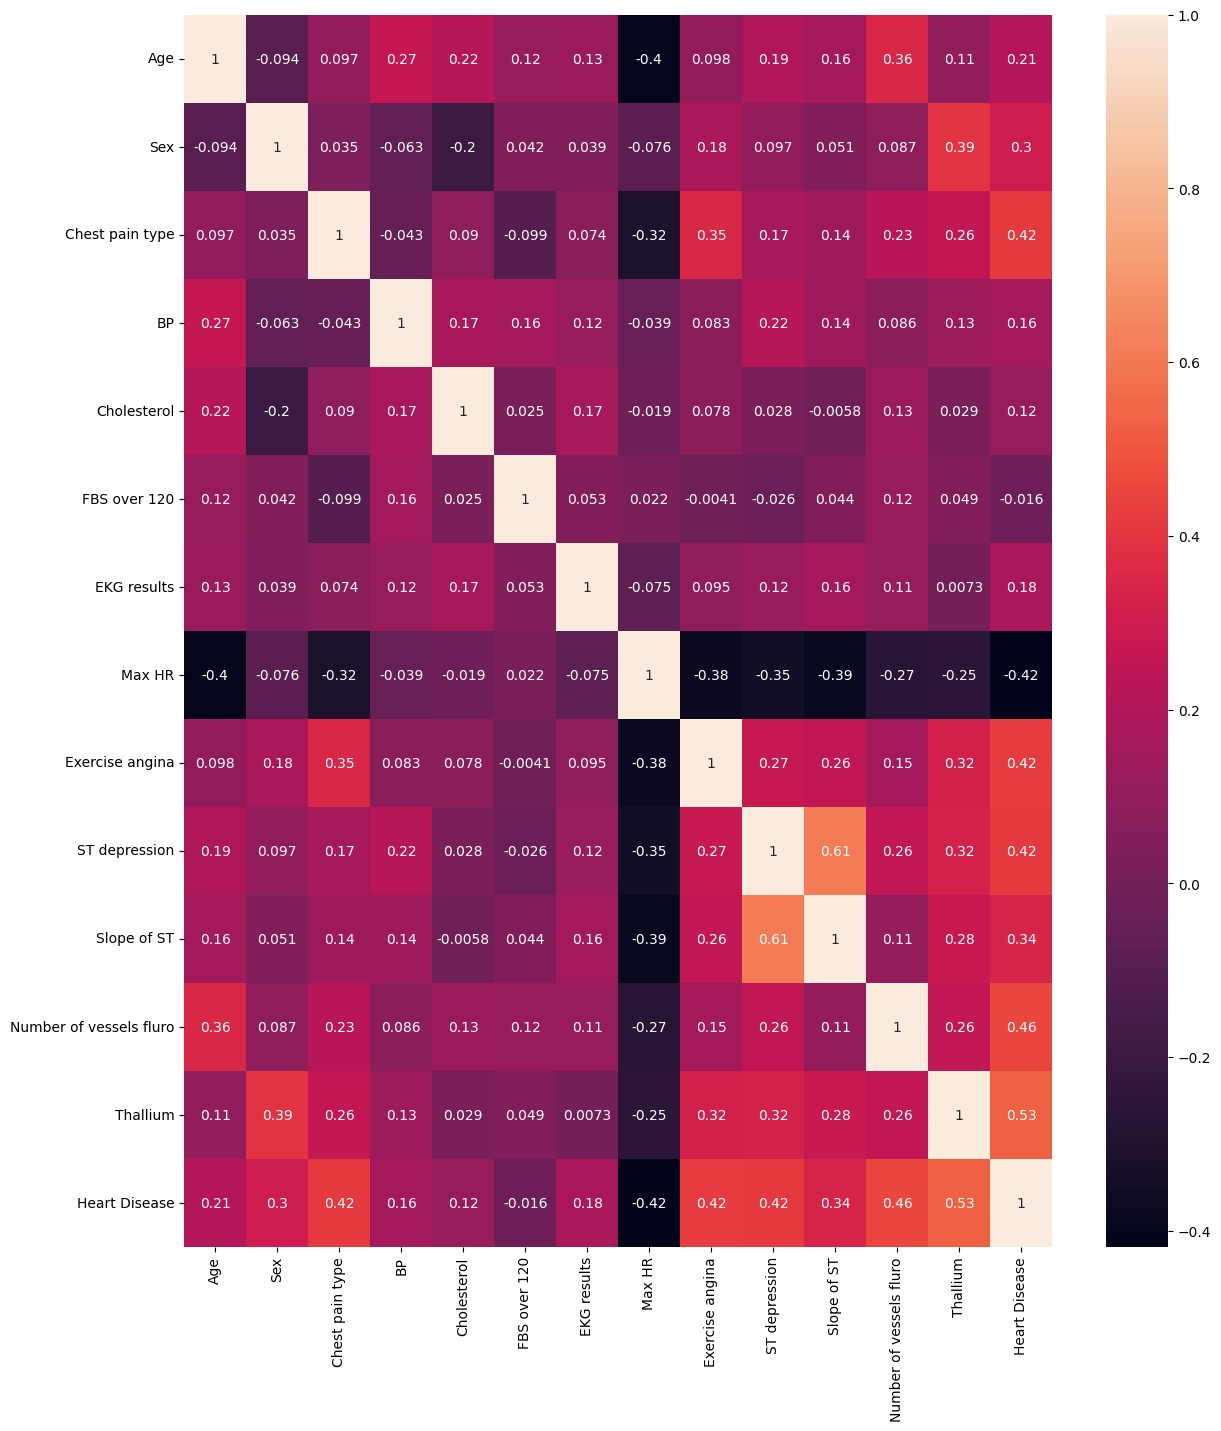

In [31]:
plt.figure(figsize=(14,16))
sns.heatmap(df.corr(numeric_only=True),annot=True,xticklabels=True)
plt.show()

## build model

In [32]:
# split the Data
from sklearn.model_selection import train_test_split

# preprocesing
from sklearn.preprocessing import StandardScaler

# The models for Classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier 
from sklearn.linear_model import LogisticRegression

# matrics
from sklearn.metrics import classification_report , accuracy_score
from sklearn.metrics import confusion_matrix


In [33]:
x = df.drop('Heart Disease',axis=1)
y = df['Heart Disease']
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size=0.25 , shuffle=True , random_state=21)

In [34]:
scl = StandardScaler()
x_train = scl.fit_transform(x_train)
x_test = scl.transform(x_test)

In [35]:
accuracies =[]

In [36]:
def evaluate_model(model):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    accuracies.append(accuracy_score(y_test, pred))
    
    print("Model Score:", round(model.score(x_test, y_test),3))
    print("Accuracy:", round(accuracy_score(y_test, pred),3))
    
    print("\nClassification Report:")
    print(classification_report(y_test, pred))
    
    sns.heatmap(
        confusion_matrix(y_test, pred),
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [37]:
model1 = SVC()

model2 = GradientBoostingClassifier()

model3 = RandomForestClassifier()

model4 = DecisionTreeClassifier()

model5 = XGBClassifier()

model6 = LogisticRegression()

model7 = GaussianNB()

model8 = KNeighborsClassifier()

## Evaluate models

Model Score: 0.824
Accuracy: 0.824

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        36
           1       0.81      0.81      0.81        32

    accuracy                           0.82        68
   macro avg       0.82      0.82      0.82        68
weighted avg       0.82      0.82      0.82        68



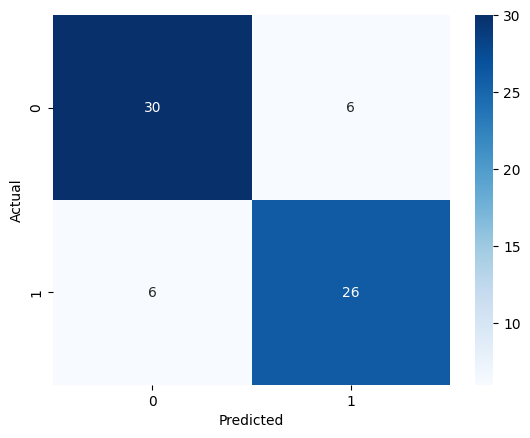

In [38]:
evaluate_model(model1)

Model Score: 0.809
Accuracy: 0.809

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        36
           1       0.79      0.81      0.80        32

    accuracy                           0.81        68
   macro avg       0.81      0.81      0.81        68
weighted avg       0.81      0.81      0.81        68



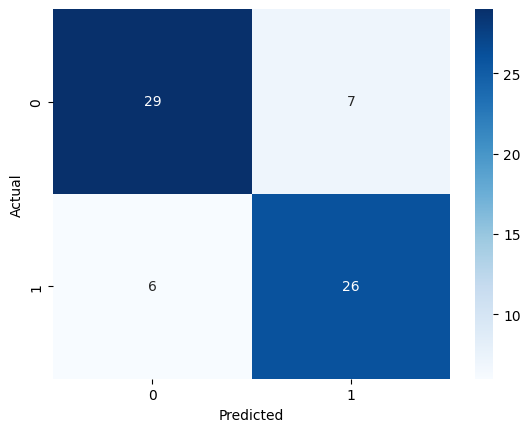

In [39]:
evaluate_model(model2)

Model Score: 0.809
Accuracy: 0.809

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        36
           1       0.85      0.72      0.78        32

    accuracy                           0.81        68
   macro avg       0.82      0.80      0.81        68
weighted avg       0.81      0.81      0.81        68



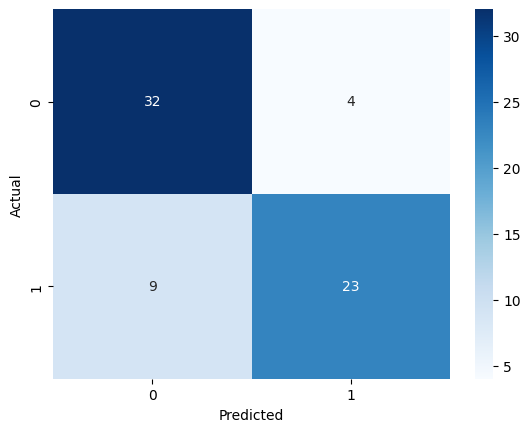

In [40]:
evaluate_model(model3)

Model Score: 0.706
Accuracy: 0.706

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        36
           1       0.69      0.69      0.69        32

    accuracy                           0.71        68
   macro avg       0.70      0.70      0.70        68
weighted avg       0.71      0.71      0.71        68



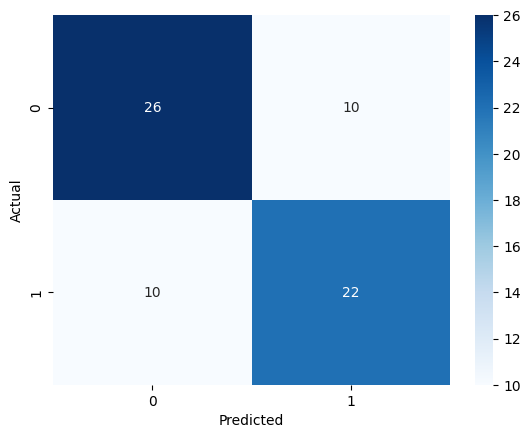

In [41]:
evaluate_model(model4)

Model Score: 0.794
Accuracy: 0.794

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        36
           1       0.80      0.75      0.77        32

    accuracy                           0.79        68
   macro avg       0.79      0.79      0.79        68
weighted avg       0.79      0.79      0.79        68



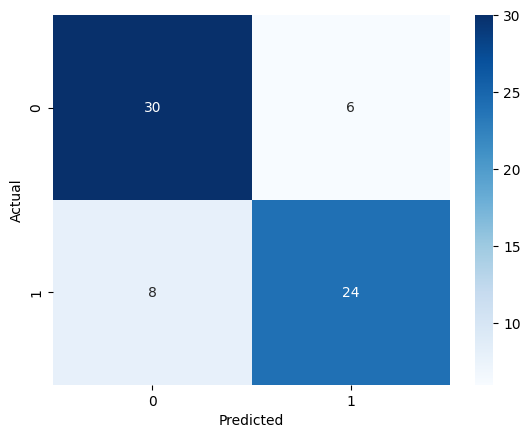

In [42]:
evaluate_model(model5)

Model Score: 0.838
Accuracy: 0.838

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        36
           1       0.89      0.75      0.81        32

    accuracy                           0.84        68
   macro avg       0.85      0.83      0.84        68
weighted avg       0.84      0.84      0.84        68



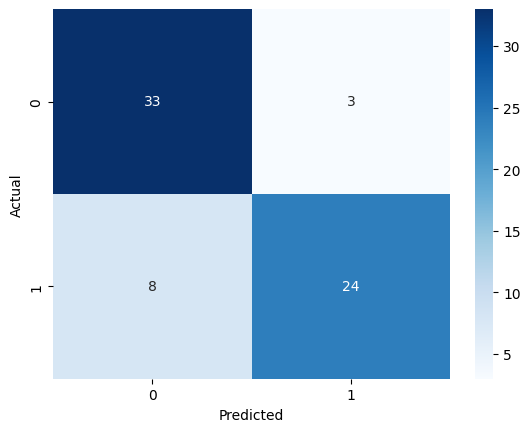

In [43]:
evaluate_model(model6)

Model Score: 0.838
Accuracy: 0.838

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        36
           1       0.84      0.81      0.83        32

    accuracy                           0.84        68
   macro avg       0.84      0.84      0.84        68
weighted avg       0.84      0.84      0.84        68



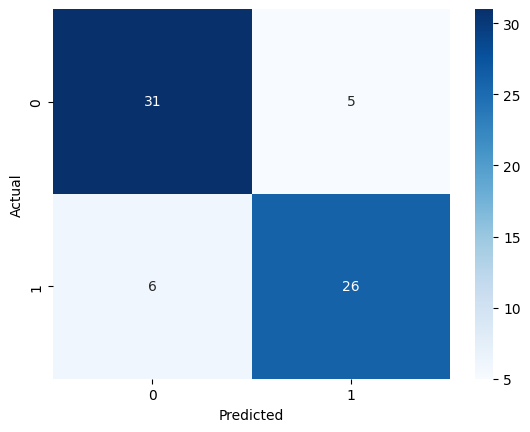

In [44]:
evaluate_model(model7)

Model Score: 0.809
Accuracy: 0.809

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        36
           1       0.79      0.81      0.80        32

    accuracy                           0.81        68
   macro avg       0.81      0.81      0.81        68
weighted avg       0.81      0.81      0.81        68



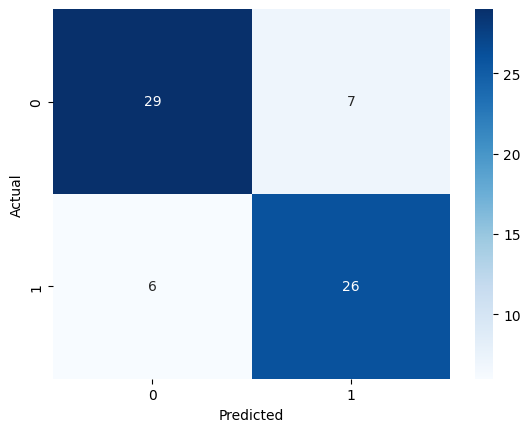

In [45]:
evaluate_model(model8)

## best model

In [46]:
Alghorisms= [ 'SVC', 'GradientBoostingClassifier', 'RandomForestClassifier', 'DecisionTreeClassifier', 'XGBClassifier', 'LogisticRegression', 'GaussianNB', 'KNeighborsClassifier' ]

In [50]:
df_models = pd.DataFrame({'Alghorisms':Alghorisms,'accuracies':accuracies})
df_models.sort_values('accuracies',ascending=False)

,Alghorisms,accuracies
6,GaussianNB,0.838235
5,LogisticRegression,0.838235
0,SVC,0.823529
1,GradientBoostingClassifier,0.808824
7,KNeighborsClassifier,0.808824
2,RandomForestClassifier,0.808824
4,XGBClassifier,0.794118
3,DecisionTreeClassifier,0.705882


In [51]:
df_models.loc[df_models['accuracies'].idxmax()]

Alghorisms    LogisticRegression
accuracies              0.838235
Name: 5, dtype: object